# 1. Make a binary classification dataset with Scikit-Learn's make_moons() function.

In [3]:
from sklearn.datasets import make_moons

n_sample = 1000

X,y = make_moons(n_samples=n_sample, random_state=42)


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


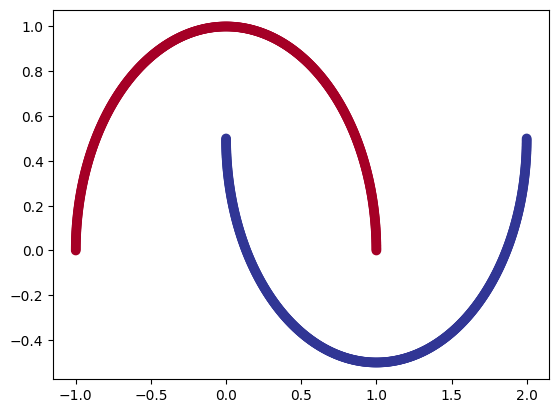

In [4]:
%pip install matplotlib
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

In [5]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[ 0.0087,  0.3682],
         [ 0.9214, -0.4969],
         [ 0.9402, -0.4982],
         [ 0.4659, -0.3454],
         [-0.8504,  0.5261]]),
 tensor([1., 1., 1., 1., 0.]))

In [6]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [7]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# 2. Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.

In [8]:
# 1. Construct a model class that subclasses nn.Module
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1),
            nn.ReLU()
        )
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.linear_layer_stack(x)

# 4. Create an instance of the model and send it to target device
model_0 = Model().to(device)
model_0

Model(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
    (5): ReLU()
  )
)

In [9]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.1056],
        [0.1987],
        [0.1050],
        [0.1996],
        [0.1278],
        [0.1439],
        [0.1591],
        [0.1353],
        [0.1036],
        [0.1979]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


# 3. Setup a binary classification compatible loss function and optimizer to use when training the model.

In [10]:
# Loss Function
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.2)

# 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.

In [11]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71016, Accuracy: 50.00% | Test loss: 0.70664, Test acc: 50.00%
Epoch: 10 | Loss: 0.67758, Accuracy: 56.62% | Test loss: 0.67726, Test acc: 56.00%
Epoch: 20 | Loss: 0.64901, Accuracy: 61.62% | Test loss: 0.65039, Test acc: 60.50%
Epoch: 30 | Loss: 0.61513, Accuracy: 62.38% | Test loss: 0.61859, Test acc: 72.50%
Epoch: 40 | Loss: 0.58086, Accuracy: 74.38% | Test loss: 0.58738, Test acc: 71.50%
Epoch: 50 | Loss: 0.55400, Accuracy: 80.00% | Test loss: 0.56291, Test acc: 76.00%
Epoch: 60 | Loss: 0.53416, Accuracy: 82.75% | Test loss: 0.54405, Test acc: 81.00%
Epoch: 70 | Loss: 0.51867, Accuracy: 84.75% | Test loss: 0.52883, Test acc: 84.00%
Epoch: 80 | Loss: 0.50573, Accuracy: 86.12% | Test loss: 0.51599, Test acc: 84.50%
Epoch: 90 | Loss: 0.49518, Accuracy: 87.12% | Test loss: 0.50498, Test acc: 86.00%
Epoch: 100 | Loss: 0.48634, Accuracy: 87.88% | Test loss: 0.49560, Test acc: 86.50%
Epoch: 110 | Loss: 0.47867, Accuracy: 88.62% | Test loss: 0.48756, Test acc: 87.00%
Epo

# 5. Make predictions with your trained model and plot them using the plot_decision_boundary() function created in this notebook.

In [13]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

ModuleNotFoundError: No module named 'requests'

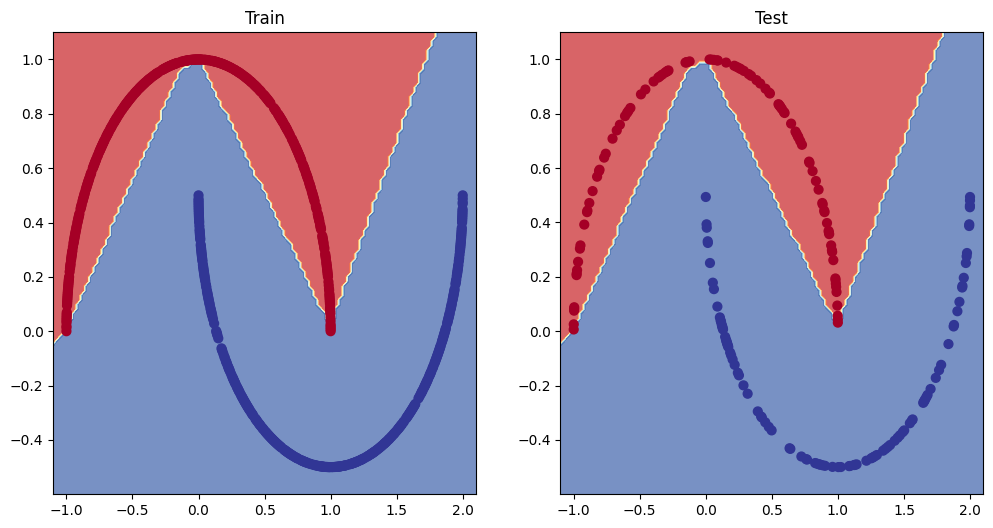

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
    * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

In [ ]:
def my_tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

In [ ]:
# Hàm Tanh của Pytorch
m = nn.Tanh()
input = torch.randn(2)
output = m(input)
output_1 = my_tanh(input)

# So sánh kết quả
print(output)
print(output_1)

tensor([0.3245, 0.1281])
tensor([0.3245, 0.1281])


# 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
    * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
    * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
    * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like).
    * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.



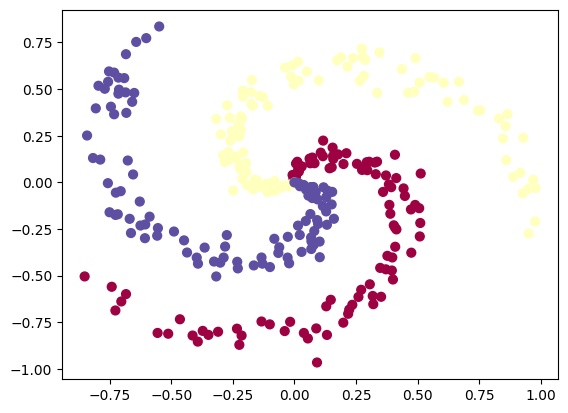

In [ ]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt

N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X_s = np.zeros((N*K,D)) # data matrix (each row = single example)
y_s = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X_s[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y_s[ix] = j
# lets visualize the data
plt.scatter(X_s[:, 0], X_s[:, 1], c=y_s, s=40, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
import torch
# Turn data into tensors
# Otherwise this causes issues with computations later on
X_spiral = torch.from_numpy(X_s).type(torch.float)
y_spiral = torch.from_numpy(y_s).type(torch.LongTensor)

# View the first five samples
X_spiral[:10], y_spiral[:10]

(tensor([[ 0.0000,  0.0000],
         [-0.0016,  0.0100],
         [-0.0039,  0.0198],
         [ 0.0062,  0.0297],
         [-0.0075,  0.0397],
         [ 0.0104,  0.0494],
         [ 0.0180,  0.0579],
         [ 0.0154,  0.0690],
         [ 0.0233,  0.0774],
         [ 0.0299,  0.0859]]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [ ]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_spiral_train, X_spiral_test, y_spiral_train, y_spiral_test = train_test_split(X_spiral,
                                                    y_spiral,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_spiral_train), len(X_spiral_test), len(y_spiral_train), len(y_spiral_test)


(240, 60, 240, 60)

In [ ]:
X_spiral_train.shape, y_spiral_train.shape

(torch.Size([240, 2]), torch.Size([240]))

In [ ]:
from torch import nn

# Build model
class SpiralModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of SpiralModel and send it to the target device
model_3 = SpiralModel(input_features=D,
                    output_features=K,
                    hidden_units=8).to(device)
model_3

SpiralModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [ ]:
# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.0025)


In [ ]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_3(X_spiral_train.to(device))[:5]

tensor([[-0.2415, -0.2485, -0.1767],
        [-0.2630, -0.2614, -0.1743],
        [-0.2416, -0.2442, -0.1757],
        [-0.2992, -0.2624, -0.1854],
        [-0.2741, -0.2523, -0.1763]], grad_fn=<SliceBackward0>)

In [ ]:
# How many elements in a single prediction sample?
model_3(X_spiral_train.to(device))[0].shape, 3

(torch.Size([3]), 3)

In [ ]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 1000

# Put data to target device
X_spiral_train, y_spiral_train = X_spiral_train.to(device), y_spiral_train.to(device)
X_spiral_test, y_spiral_test = X_spiral_test.to(device), y_spiral_test.to(device)

for epoch in range(epochs):
    ### Training
    model_3.train()

    # 1. Forward pass
    y_logits = model_3(X_spiral_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_spiral_train)
    acc = accuracy_fn(y_true=y_spiral_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_3(X_spiral_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_spiral_test)
      test_acc = accuracy_fn(y_true=y_spiral_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.10898, Acc: 35.00% | Test Loss: 1.13747, Test Acc: 26.67%
Epoch: 10 | Loss: 1.09664, Acc: 35.00% | Test Loss: 1.11928, Test Acc: 26.67%
Epoch: 20 | Loss: 1.08284, Acc: 35.00% | Test Loss: 1.10087, Test Acc: 26.67%
Epoch: 30 | Loss: 1.06682, Acc: 35.00% | Test Loss: 1.08240, Test Acc: 28.33%
Epoch: 40 | Loss: 1.04848, Acc: 41.67% | Test Loss: 1.06283, Test Acc: 36.67%
Epoch: 50 | Loss: 1.02582, Acc: 45.00% | Test Loss: 1.03997, Test Acc: 41.67%
Epoch: 60 | Loss: 0.99843, Acc: 57.08% | Test Loss: 1.01289, Test Acc: 51.67%
Epoch: 70 | Loss: 0.96689, Acc: 60.83% | Test Loss: 0.98191, Test Acc: 53.33%
Epoch: 80 | Loss: 0.93263, Acc: 56.67% | Test Loss: 0.94792, Test Acc: 48.33%
Epoch: 90 | Loss: 0.89585, Acc: 57.92% | Test Loss: 0.91343, Test Acc: 51.67%
Epoch: 100 | Loss: 0.85914, Acc: 59.17% | Test Loss: 0.88072, Test Acc: 53.33%
Epoch: 110 | Loss: 0.82446, Acc: 60.42% | Test Loss: 0.85040, Test Acc: 53.33%
Epoch: 120 | Loss: 0.79245, Acc: 60.00% | Test Loss: 0.82320, T

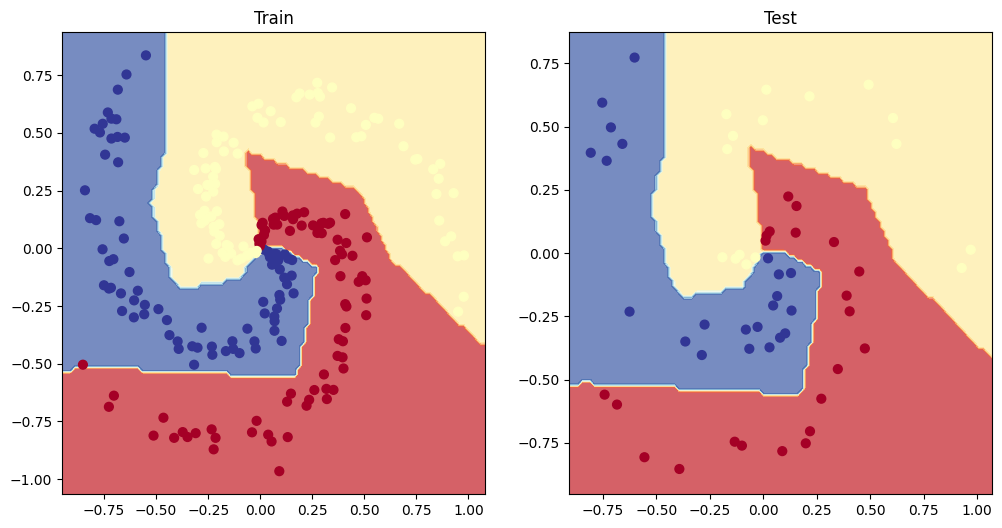

In [ ]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_spiral_train, y_spiral_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_spiral_test, y_spiral_test)